In [1]:
import xarray as xr

fsm = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge = xr.open_dataset("../data/processed/senorge_all.nc")
snow = xr.open_dataset("../data/processed/snowpack_all.nc")

print(fsm)
print(senorge)
print(snow)

<xarray.Dataset> Size: 11GB
Dimensions:      (time: 1461, y: 1550, x: 1195)
Coordinates:
  * time         (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * y            (y) float64 12kB 6.45e+06 6.451e+06 ... 7.998e+06 7.999e+06
  * x            (x) float64 10kB -7.5e+04 -7.4e+04 ... 1.118e+06 1.119e+06
    lon          (y, x) float64 15MB ...
    lat          (y, x) float64 15MB ...
Data variables:
    snow_depth   (time, y, x) float32 11GB ...
    UTM_Zone_33  (time) float64 12kB ...
Attributes:
    title:        Snow depth
    institution:  NVE
    source:       ConvertTo-Grid
    history:      Initial
    references:   http://www.xgeo.no/
    comment:      Snow depth simulated by the FSM2 model run at NVE and force...
    Conventions:  CF-1.6
<xarray.Dataset> Size: 22GB
Dimensions:                (time: 1461, y: 1550, x: 1195)
Coordinates:
  * time                   (time) datetime64[ns] 12kB 2022-01-01 ... 2025-12-31
  * y                      (y) float64 12kB 6.

In [3]:
senorge["snow_depth"] = senorge["snow_depth"] * 10
snow["HS_mod"] = snow["HS_mod"] * 10

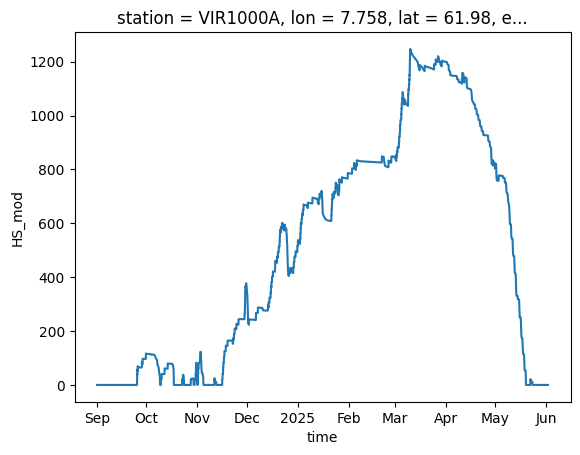

In [4]:
snow.sel(station="VIR1000A")["HS_mod"].plot()

In [7]:
senorge_point = senorge.sel(
    x=snow.sel(station="VIR1000A")["x"],
    y=snow.sel(station="VIR1000A")["y"],
    method="nearest"
)

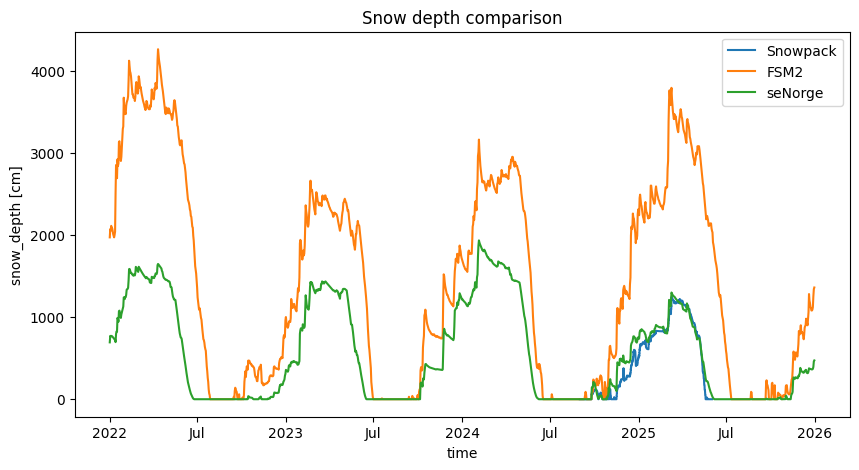

In [9]:
import matplotlib.pyplot as plt

snow_series = snow.sel(station="VIR1000A")["HS_mod"]
fsm_series = fsm_point["snow_depth"]
sen_series = senorge_point["snow_depth"]

plt.figure(figsize=(10,5))

snow_series.plot(label="Snowpack")
fsm_series.plot(label="FSM2")
sen_series.plot(label="seNorge")

plt.legend()
plt.title("Snow depth comparison")
plt.show()

In [10]:
bias = (fsm_series - snow_series).mean()

In [11]:
rmse = (((fsm_series - snow_series) ** 2).mean()) ** 0.5

In [12]:
corr = xr.corr(fsm_series, snow_series)

In [13]:
print("Bias:", float(bias))
print("RMSE:", float(rmse))
print("Correlation:", float(corr))

Bias: 1352.4456043956045
RMSE: 1589.6034535649808
Correlation: 0.897394927198325


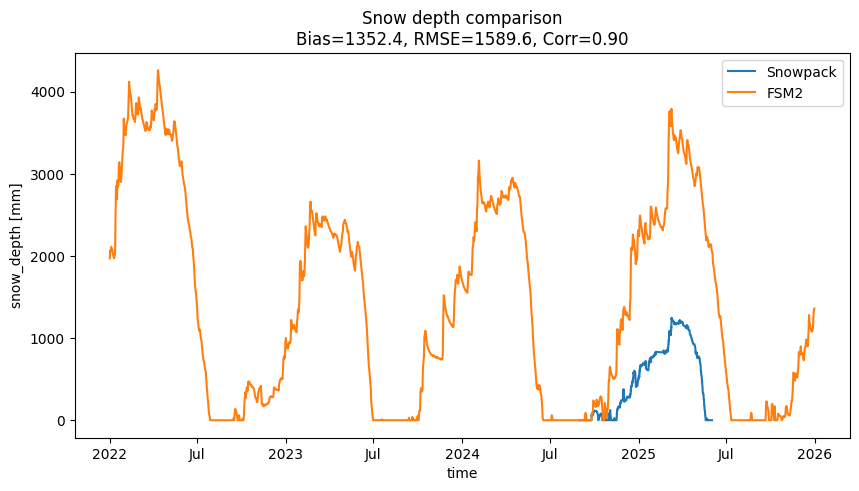

In [14]:
plt.figure(figsize=(10,5))

snow_series.plot(label="Snowpack")
fsm_series.plot(label="FSM2")

plt.legend()

plt.title(
    f"Snow depth comparison\nBias={bias.values:.1f}, RMSE={rmse.values:.1f}, Corr={corr.values:.2f}"
)

plt.show()